# ML vs MPRA Enhancer Activities

In [1]:
import pandas as pd
import numpy as np
folders = [
    'H1_IFNB-model-best',
    'H1_resting-model',
    'HEK293_ATAC_high_depth0729',
    'HEK293T_ATAC',
    'Mouse_Cortex_AgeB-model',
    'Mouse_Cortex_AgeC-model',
    'Mouse_Striatum_AgeB',
    'Mouse_Striatum_AgeC',
    'THP1_IFNB-Calvin',
    'THP1_IFNG-Calvin',
    'THP1_LPSIFNG-Calvin',
    'THP1_monocyte0729',
    'THP1_Naive-Calvin',
    'WTC11_IFNB',
    'WTC11_resting',
    'fullard_hippocampus-model-best',
    'fullard_putamen-model-best',
    'fullard_DLPFC-model-best',
    'astrocyte_GSE188398-model-best',
    'oligodendrocyte_GSE143666-model-best'
]

pairs = []
for f in folders:
    pairs.append((
        f'prediction/10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences/{f}_20240826_MPRA_500bp_SNPandControl_500bpbarcodes_one.csv',
        f'prediction/10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences_negative/{f}_20240826_MPRA_500bp_SNPandControl_500bpbarcodes_one.csv',
        f
    ))

index_csv_path = '../../mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_variant_category_20260310.csv'

all_normalized_pos = pd.DataFrame()
for (file1, file2, model) in pairs:
    # Load and process the positive dataset
    df_pos = pd.read_csv(file1, header=None)
    
    df_pos = df_pos.groupby(df_pos.index // 2).mean()
    df_pos = df_pos/df_pos.std()
    all_normalized_pos[model] = (np.array(df_pos.loc[:854][0]) + np.array(df_pos.loc[855:][0]))/2
all_normalized_pos
df_index = pd.read_csv(index_csv_path ,index_col=0)
df_index["rsid_gene_label"] = df_index['rsID']+"("+df_index['closest_protein_coding_gene_TSS']+") "+df_index['hierarchical_label']
df_index_unique = df_index.drop_duplicates(subset=['rsID'])
all_normalized_pos.index = df_index.index
all_normalized_pos = pd.merge(all_normalized_pos,df_index[['Variant_Category']],left_index=True,right_index=True)
df_mpra_annotation_ml_unique = all_normalized_pos.loc[df_index_unique.index]
df_mpra_annotation_ml_unique

,H1_IFNB-model-best,H1_resting-model,HEK293_ATAC_high_depth0729,HEK293T_ATAC,Mouse_Cortex_AgeB-model,Mouse_Cortex_AgeC-model,Mouse_Striatum_AgeB,Mouse_Striatum_AgeC,THP1_IFNB-Calvin,THP1_IFNG-Calvin,...,THP1_monocyte0729,THP1_Naive-Calvin,WTC11_IFNB,WTC11_resting,fullard_hippocampus-model-best,fullard_putamen-model-best,fullard_DLPFC-model-best,astrocyte_GSE188398-model-best,oligodendrocyte_GSE143666-model-best,Variant_Category
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,0.739812,0.871919,1.663029,1.298423,1.288348,1.081622,0.699427,1.475895,0.704112,0.748530,...,1.185782,0.844090,0.241081,0.398868,0.335830,0.781841,1.209817,1.589819,3.321103,Broad
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,1.054724,0.478406,0.597072,1.974317,0.965121,0.989271,0.908790,0.908552,1.847054,1.712287,...,1.875720,1.330564,0.970826,0.853211,0.634982,0.209708,1.051942,0.141617,2.151213,Low-ATAC
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,0.545633,0.826281,1.945458,3.466589,0.395425,0.603120,0.873304,1.239301,0.569418,0.664721,...,1.195169,1.082267,0.647537,0.740900,0.258822,0.814861,0.939088,0.808107,2.087356,Broad
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,0.143361,0.164996,0.282703,0.196574,0.187631,0.221715,0.395151,0.903968,0.108145,0.100242,...,0.322992,0.090068,0.043979,0.033554,0.084992,0.668085,0.150748,0.338323,0.228034,Immune-enriched
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,0.345807,0.504530,0.523458,0.520137,0.152806,0.189731,1.143127,0.940192,0.192408,0.580150,...,0.598363,0.114422,0.104033,0.172459,0.053659,0.266144,0.105408,0.176159,0.316580,Broad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
alt:rs9478143:PEAKCENTER:chr6:150862035:A:G:150861632:150862271:150862051,2.836547,3.435268,0.813155,1.955370,1.869328,1.371923,0.732765,0.708246,2.325822,2.868112,...,2.695653,2.208644,3.062690,2.755468,2.463445,1.021593,2.638667,0.411205,1.751223,Immune-enriched
alt:rs953471:PEAKCENTER:chr9:124221903:G:A:124221758:124221963:124221854,1.037577,1.122686,0.785088,0.786028,0.530978,0.628304,3.742551,4.338916,0.454009,0.781064,...,1.961551,0.801226,1.622041,1.310494,0.406986,2.949443,0.914867,0.973815,1.495627,Immune-enriched
alt:rs965034941:SNPCENTER:chr19:1999195:CCA:C:1999082:1999308:1999195,0.832868,0.168892,0.216487,0.351317,0.548567,0.786050,0.449008,0.883729,1.885564,1.622456,...,0.929226,0.922003,0.482063,0.570244,0.219357,0.835402,0.184052,0.686498,0.457240,Immune-enriched


In [4]:
df_mpra_annotation_ml_unique['Variant_Category'].unique()

array(['Broad', 'Low-ATAC', 'Immune-enriched', 'Neuronal-enriched',
       'Glial-enriched'], dtype=object)

In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt
# Collect all mad.score series along with their indices
all_scores = []
names = []
base_dir = "../../mpra3_lib_analysis/enhancer_activities/MAD_OneTail_NoControl"
for f in os.listdir(base_dir):
    if f.endswith('.csv'):
        folder_path = os.path.join(base_dir, f)

        df_tmp = pd.read_csv(folder_path, index_col=0)
        mad = df_tmp['mad.score']
        names.append(f[13:-4])
        all_scores.append(mad)

# Find common index (intersection of all indices)
common_index = all_scores[0].index
for score in all_scores[1:]:
    common_index = common_index.intersection(score.index)

# Reindex all mad.score series to the common index
final_scores = []
for score in all_scores:
    reindexed_score = score.reindex(common_index)
    final_scores.append(reindexed_score)

# Create DataFrame from the reindexed scores
final_df = pd.DataFrame(final_scores, index=names).T


In [5]:

############################################################
# Step 7: Additional Comparisons Based on Variant_Category
############################################################

df_immune = df_mpra_annotation_ml_unique[df_mpra_annotation_ml_unique['Variant_Category'] == 'Immune-enriched']
df_other = df_mpra_annotation_ml_unique[df_mpra_annotation_ml_unique['Variant_Category'] == 'Low-ATAC']
df_ubiquitous = df_mpra_annotation_ml_unique[df_mpra_annotation_ml_unique['Variant_Category'] == 'Broad']
df_glia = df_mpra_annotation_ml_unique[df_mpra_annotation_ml_unique['Variant_Category'] == 'Glial-enriched']
df_neuron = df_mpra_annotation_ml_unique[df_mpra_annotation_ml_unique['Variant_Category'] == 'Neuronal-enriched']

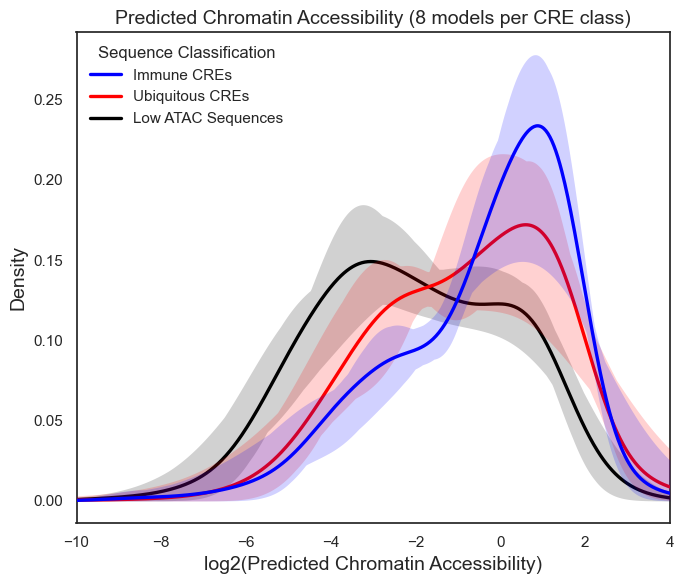

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

columns_to_combine = [
    'H1_resting-model', 'THP1_IFNB-Calvin', 'THP1_IFNG-Calvin',
    'THP1_LPSIFNG-Calvin', 'THP1_monocyte0729', 'THP1_Naive-Calvin',
    'WTC11_IFNB', 'WTC11_resting'
]

# 三类数据表：df_other / df_immune / df_ubiquitous
GROUPS = {
    "Immune CREs": df_immune,
    "Ubiquitous CREs": df_ubiquitous,
    "Low ATAC Sequences": df_other,
}

# 用你源代码的颜色（更“纯”）
COLORS = {
    "Immune CREs": "blue",
    "Ubiquitous CREs": "red",
    "Low ATAC Sequences": "black",
}

def safe_log2(arr, eps=1e-8):
    arr = np.asarray(arr, dtype=float)
    arr = np.clip(arr, eps, None)
    out = np.log2(arr)
    return out[np.isfinite(out)]

def kde_on_grid(x, grid, bw_adjust=1.0):
    x = np.asarray(x, dtype=float)
    if x.size < 5:
        return None
    kde = gaussian_kde(x, bw_method=lambda k: k.scotts_factor() * bw_adjust)
    return kde(grid)

# --- plot settings ---
x_min, x_max = -10, 4
grid = np.linspace(x_min, x_max, 600)
ci_lo, ci_hi = 2.5, 97.5   # 95% band
bw_adjust = 1.0

show_thin_model_lines = False  # 只想要 band+mean 就 False
thin_alpha = 0.10              # 如果 show_thin_model_lines=True, 这个控制8条线淡不淡
band_alpha = 0.18

plt.figure(figsize=(7, 6))

# 控制叠放层级：immune 最上
Z = {"Immune CREs": 30, "Ubiquitous CREs": 20, "Low ATAC Sequences": 10}

for group_name, dfg in GROUPS.items():
    densities = []

    for col in columns_to_combine:
        vals = safe_log2(dfg[col].to_numpy())
        dens = kde_on_grid(vals, grid, bw_adjust=bw_adjust)
        if dens is None:
            continue
        densities.append(dens)

        if show_thin_model_lines:
            plt.plot(
                grid, dens,
                color=COLORS[group_name],
                alpha=thin_alpha,
                linewidth=1.0,
                zorder=Z[group_name] - 2
            )

    densities = np.vstack(densities)

    mean_d = densities.mean(axis=0)
    lo = np.percentile(densities, ci_lo, axis=0)
    hi = np.percentile(densities, ci_hi, axis=0)

    # 先画 interval（更底层）
    plt.fill_between(
        grid, lo, hi,
        color=COLORS[group_name],
        alpha=band_alpha,
        linewidth=0,
        zorder=Z[group_name] - 1
    )

    # 再画 mean（确保在 band 上面）
    plt.plot(
        grid, mean_d,
        color=COLORS[group_name],
        linewidth=2.4,
        zorder=Z[group_name],
        label=group_name
    )

plt.xlabel("log2(Predicted Chromatin Accessibility)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.title("Predicted Chromatin Accessibility (8 models per CRE class)", fontsize=14)
plt.xlim(x_min, x_max)
# plt.ylim(0, 0.45)

plt.legend(title="Sequence Classification", frameon=False)
plt.tight_layout()
plt.show()


In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="white", font="Arial")

############################################################
# Step 7: Additional Comparisons Based on Variant_Category
############################################################

df_immune = df_mpra_annotation_ml_unique[
    df_mpra_annotation_ml_unique['Variant_Category'] == 'Immune-enriched'
].copy()

df_other = df_mpra_annotation_ml_unique[
    df_mpra_annotation_ml_unique['Variant_Category'] == 'Low-ATAC'
].copy()

df_ubiquitous = df_mpra_annotation_ml_unique[
    df_mpra_annotation_ml_unique['Variant_Category'] == 'Broad'
].copy()

df_glia = df_mpra_annotation_ml_unique[
    df_mpra_annotation_ml_unique['Variant_Category'] == 'Glial-enriched'
].copy()

df_neuron = df_mpra_annotation_ml_unique[
    df_mpra_annotation_ml_unique['Variant_Category'] == 'Neuronal-enriched'
].copy()


n Low-ATAC: 836
n Immune: 2204
n Broad: 1780
n Glia: 196
n Neuronal: 340


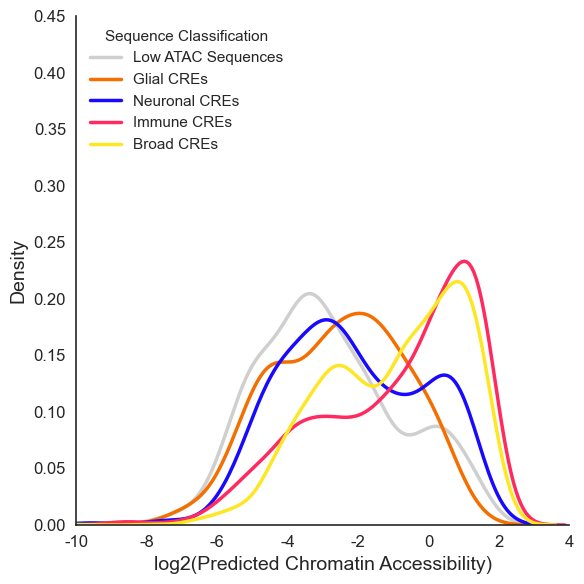

In [25]:

columns_to_combine = [
    'H1_IFNB-model-best',
    'H1_resting-model',
    'THP1_IFNB-Calvin',
    'THP1_IFNG-Calvin',
    'THP1_LPSIFNG-Calvin',
    'THP1_monocyte0729',
    'THP1_Naive-Calvin',
    'WTC11_IFNB',
    'WTC11_resting'
]

# ----------------------------------------------------------
# Helper: flatten -> numeric -> remove NA -> keep > 0
# ----------------------------------------------------------
def get_log2_values(df, cols):
    vals = pd.to_numeric(
        pd.Series(df[cols].values.flatten()),
        errors='coerce'
    ).dropna()
    vals = vals[vals > 0]
    return np.log2(vals)

combined_values_other = get_log2_values(df_other, columns_to_combine)
combined_values_immune = get_log2_values(df_immune, columns_to_combine)
combined_values_ubiquitous = get_log2_values(df_ubiquitous, columns_to_combine)
combined_values_glia = get_log2_values(df_glia, columns_to_combine)
combined_values_neuron = get_log2_values(df_neuron, columns_to_combine)

print("n Low-ATAC:", len(combined_values_other))
print("n Immune:", len(combined_values_immune))
print("n Broad:", len(combined_values_ubiquitous))
print("n Glia:", len(combined_values_glia))
print("n Neuronal:", len(combined_values_neuron))

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
sns.set_style("white")

color_map = {
    'Low ATAC Sequences': '#CFCFCF',
    'Immune CREs': '#ff2a60',
    'Broad CREs': '#fde725',
    'Glial CREs': '#f46e00',
    'Neuronal CREs': '#180aff',
}

plot_data = [
    (combined_values_other, 'Low ATAC Sequences'),
    (combined_values_glia, 'Glial CREs'),
    (combined_values_neuron, 'Neuronal CREs'),
    (combined_values_immune, 'Immune CREs'),
    (combined_values_ubiquitous, 'Broad CREs'),

]

plt.figure(figsize=(6, 6))

for vals, label in plot_data:
    sns.kdeplot(
        vals,
        label=label,
        color=color_map[label],
        linewidth=2.5,
        fill=False,
        common_norm=False,
        clip=(-10, 4)
    )

plt.xlabel('log2(Predicted Chromatin Accessibility)', fontsize=14)
plt.ylabel('Density', fontsize=14)
#plt.title('Predicted Chromatin Accessibility from Immune Models', fontsize=14)

plt.xlim(-10, 4)
plt.ylim(0, 0.45)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(axis='both', labelsize=12, width=1.2, length=4)

plt.legend(
    title='Sequence Classification',
    frameon=False,
    fontsize=11,
    title_fontsize=11,
    loc='upper left'
)

plt.tight_layout()
plt.savefig('density_enhancer_type_immune.pdf', dpi=300, bbox_inches='tight')
plt.show()


n Low-ATAC: 281
n Immune: 734
n Broad: 597
n Glia: 66
n Neuronal: 114


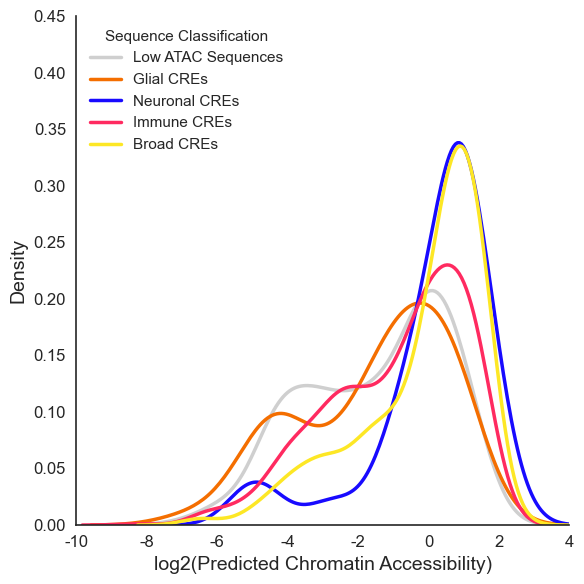

In [26]:
columns_to_combine = [
    'fullard_hippocampus-model-best',
    'fullard_putamen-model-best',
    'fullard_DLPFC-model-best',
]


# ----------------------------------------------------------
# Helper: flatten -> numeric -> remove NA -> keep > 0
# ----------------------------------------------------------
def get_log2_values(df, cols):
    vals = pd.to_numeric(
        pd.Series(df[cols].values.flatten()),
        errors='coerce'
    ).dropna()
    vals = vals[vals > 0]
    return np.log2(vals)

combined_values_other = get_log2_values(df_other, columns_to_combine)
combined_values_immune = get_log2_values(df_immune, columns_to_combine)
combined_values_ubiquitous = get_log2_values(df_ubiquitous, columns_to_combine)
combined_values_glia = get_log2_values(df_glia, columns_to_combine)
combined_values_neuron = get_log2_values(df_neuron, columns_to_combine)

print("n Low-ATAC:", len(combined_values_other))
print("n Immune:", len(combined_values_immune))
print("n Broad:", len(combined_values_ubiquitous))
print("n Glia:", len(combined_values_glia))
print("n Neuronal:", len(combined_values_neuron))

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
sns.set_style("white")

color_map = {
    'Low ATAC Sequences': '#CFCFCF',
    'Immune CREs': '#ff2a60',
    'Broad CREs': '#fde725',
    'Glial CREs': '#f46e00',
    'Neuronal CREs': '#180aff',
}

plot_data = [
    (combined_values_other, 'Low ATAC Sequences'),
    (combined_values_glia, 'Glial CREs'),
    (combined_values_neuron, 'Neuronal CREs'),
    (combined_values_immune, 'Immune CREs'),
    (combined_values_ubiquitous, 'Broad CREs'),

]

plt.figure(figsize=(6, 6))

for vals, label in plot_data:
    sns.kdeplot(
        vals,
        label=label,
        color=color_map[label],
        linewidth=2.5,
        fill=False,
        common_norm=False,
        clip=(-10, 4)
    )

plt.xlabel('log2(Predicted Chromatin Accessibility)', fontsize=14)
plt.ylabel('Density', fontsize=14)
#plt.title('Predicted Chromatin Accessibility from Immune Models', fontsize=14)

plt.xlim(-10, 4)
plt.ylim(0, 0.45)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(axis='both', labelsize=12, width=1.2, length=4)

plt.legend(
    title='Sequence Classification',
    frameon=False,
    fontsize=11,
    title_fontsize=11,
    loc='upper left'
)

plt.tight_layout()
plt.savefig('density_enhancer_type_neuron.pdf', dpi=300, bbox_inches='tight')
plt.show()


n Low-ATAC: 366
n Immune: 970
n Broad: 792
n Glia: 88
n Neuronal: 151


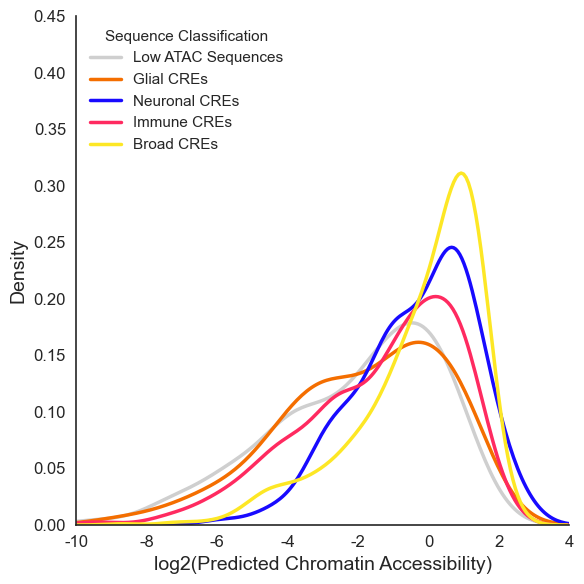

In [27]:
columns_to_combine = [
    'Mouse_Cortex_AgeB-model',
    'Mouse_Cortex_AgeC-model',
    'Mouse_Striatum_AgeB',
    'Mouse_Striatum_AgeC'
]


# ----------------------------------------------------------
# Helper: flatten -> numeric -> remove NA -> keep > 0
# ----------------------------------------------------------
def get_log2_values(df, cols):
    vals = pd.to_numeric(
        pd.Series(df[cols].values.flatten()),
        errors='coerce'
    ).dropna()
    vals = vals[vals > 0]
    return np.log2(vals)

combined_values_other = get_log2_values(df_other, columns_to_combine)
combined_values_immune = get_log2_values(df_immune, columns_to_combine)
combined_values_ubiquitous = get_log2_values(df_ubiquitous, columns_to_combine)
combined_values_glia = get_log2_values(df_glia, columns_to_combine)
combined_values_neuron = get_log2_values(df_neuron, columns_to_combine)

print("n Low-ATAC:", len(combined_values_other))
print("n Immune:", len(combined_values_immune))
print("n Broad:", len(combined_values_ubiquitous))
print("n Glia:", len(combined_values_glia))
print("n Neuronal:", len(combined_values_neuron))

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
sns.set_style("white")

color_map = {
    'Low ATAC Sequences': '#CFCFCF',
    'Immune CREs': '#ff2a60',
    'Broad CREs': '#fde725',
    'Glial CREs': '#f46e00',
    'Neuronal CREs': '#180aff',
}

plot_data = [
    (combined_values_other, 'Low ATAC Sequences'),
    (combined_values_glia, 'Glial CREs'),
    (combined_values_neuron, 'Neuronal CREs'),
    (combined_values_immune, 'Immune CREs'),
    (combined_values_ubiquitous, 'Broad CREs'),

]

plt.figure(figsize=(6, 6))

for vals, label in plot_data:
    sns.kdeplot(
        vals,
        label=label,
        color=color_map[label],
        linewidth=2.5,
        fill=False,
        common_norm=False,
        clip=(-10, 4)
    )

plt.xlabel('log2(Predicted Chromatin Accessibility)', fontsize=14)
plt.ylabel('Density', fontsize=14)
#plt.title('Predicted Chromatin Accessibility from Immune Models', fontsize=14)

plt.xlim(-10, 4)
plt.ylim(0, 0.45)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(axis='both', labelsize=12, width=1.2, length=4)

plt.legend(
    title='Sequence Classification',
    frameon=False,
    fontsize=11,
    title_fontsize=11,
    loc='upper left'
)

plt.tight_layout()
plt.savefig('density_enhancer_type_brain.pdf', dpi=300, bbox_inches='tight')
plt.show()


n Low-ATAC: 188
n Immune: 488
n Broad: 398
n Glia: 44
n Neuronal: 76


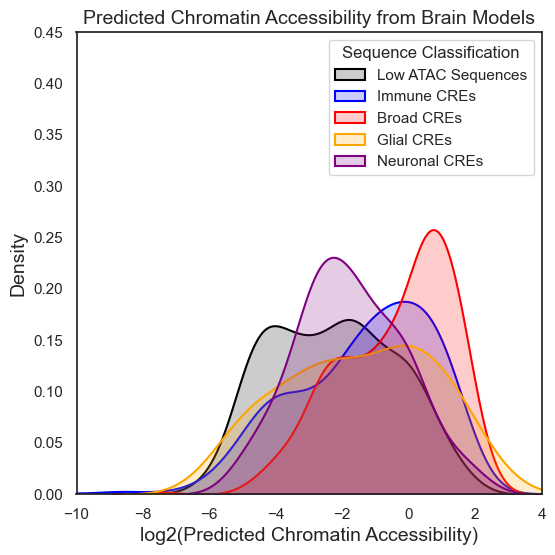

In [49]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

columns_to_combine = [
    'astrocyte_GSE188398-model-best',
    'oligodendrocyte_GSE143666-model-best'
]

# ----------------------------------------------------------
# Helper: flatten -> numeric -> remove NA -> keep > 0
# ----------------------------------------------------------
def get_log2_values(df, cols):
    vals = pd.to_numeric(
        pd.Series(df[cols].values.flatten()),
        errors='coerce'
    ).dropna()
    vals = vals[vals > 0]
    return np.log2(vals)

combined_values_immune = get_log2_values(df_immune, columns_to_combine)
combined_values_other = get_log2_values(df_other, columns_to_combine)
combined_values_ubiquitous = get_log2_values(df_ubiquitous, columns_to_combine)
combined_values_glia = get_log2_values(df_glia, columns_to_combine)
combined_values_neuron = get_log2_values(df_neuron, columns_to_combine)

print("n Low-ATAC:", len(combined_values_other))
print("n Immune:", len(combined_values_immune))
print("n Broad:", len(combined_values_ubiquitous))
print("n Glia:", len(combined_values_glia))
print("n Neuronal:", len(combined_values_neuron))

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
sns.set(style="white")

plt.figure(figsize=(6, 6))

sns.kdeplot(
    combined_values_other,
    label='Low ATAC Sequences',
    color='black',
    linestyle='-',
    linewidth=1.5,
    fill=True,
    alpha=0.2
)

sns.kdeplot(
    combined_values_immune,
    label='Immune CREs',
    color='blue',
    linestyle='-',
    linewidth=1.5,
    fill=True,
    alpha=0.2
)

sns.kdeplot(
    combined_values_ubiquitous,
    label='Broad CREs',
    color='red',
    linestyle='-',
    linewidth=1.5,
    fill=True,
    alpha=0.2
)

sns.kdeplot(
    combined_values_glia,
    label='Glial CREs',
    color='orange',
    linestyle='-',
    linewidth=1.5,
    fill=True,
    alpha=0.2
)

sns.kdeplot(
    combined_values_neuron,
    label='Neuronal CREs',
    color='purple',
    linestyle='-',
    linewidth=1.5,
    fill=True,
    alpha=0.2
)

plt.xlabel('log2(Predicted Chromatin Accessibility)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xlim(-10, 4)
plt.ylim(0, 0.45)
plt.title('Predicted Chromatin Accessibility from Brain Models', fontsize=14)

plt.legend(title='Sequence Classification')

# plt.savefig('densityplot_enhancer_type_brain.pdf', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2483302/38785685.py:11: RuntimeWarning: invalid value encountered in log2
  sns.kdeplot(np.log2(combined_values_other), label='Low ATAC Sequences', color='black', linestyle='-', linewidth=1.5,fill=True)
/tmp/ipykernel_2483302/38785685.py:12: RuntimeWarning: invalid value encountered in log2
  sns.kdeplot(np.log2(combined_values_immune), label='Immune CREs', color='blue', linestyle='-', linewidth=1.5,fill=True)
/tmp/ipykernel_2483302/38785685.py:13: RuntimeWarning: invalid value encountered in log2
  sns.kdeplot(np.log2(combined_values_ubiquitous), label='Ubiquitous CREs', color='red', linestyle='-', linewidth=1.5,fill=True)


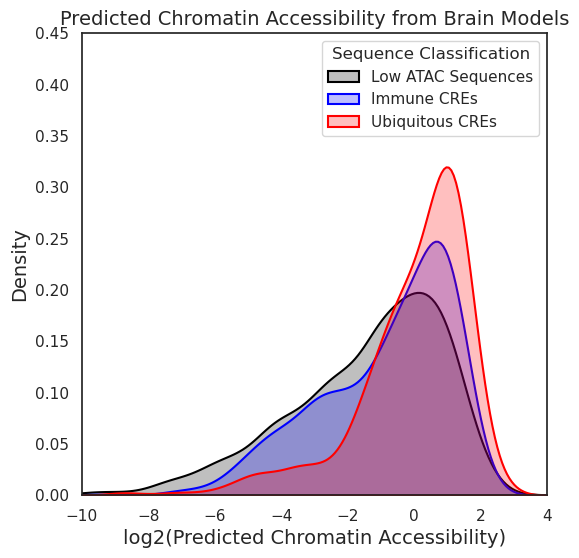

In [ ]:
columns_to_combine = ['Mouse_Cortex_AgeB-model', 'Mouse_Cortex_AgeC-model',
       'Mouse_Striatum_AgeB', 'Mouse_Striatum_AgeC']

combined_values_immune = df_immune[columns_to_combine].values.flatten().tolist()
combined_values_other = df_other[columns_to_combine].values.flatten().tolist()
combined_values_ubiquitous = df_ubiquitous[columns_to_combine].values.flatten().tolist()
# Set the style
sns.set(style="white")
# Create the plot
plt.figure(figsize=(6, 6))
sns.kdeplot(np.log2(combined_values_other), label='Low ATAC Sequences', color='black', linestyle='-', linewidth=1.5,fill=True)
sns.kdeplot(np.log2(combined_values_immune), label='Immune CREs', color='blue', linestyle='-', linewidth=1.5,fill=True)
sns.kdeplot(np.log2(combined_values_ubiquitous), label='Ubiquitous CREs', color='red', linestyle='-', linewidth=1.5,fill=True)
#sns.kdeplot(combined_values_other, label='Low ATAC Sequences', color='black', linestyle='-', linewidth=1.5,fill=True,clip=(0, None),)
#sns.kdeplot(combined_values_ubiquitous, label='Ubiquitous CREs', color='red', linestyle='-', linewidth=1.5,fill=True,clip=(0, None),)
# Adding labels and title
plt.xlabel(f'log2(Predicted Chromatin Accessibility)',fontsize=14)
plt.ylabel('Density',fontsize=14),
plt.xlim(-10,4)
plt.ylim(0,0.45)
plt.title(f'Predicted Chromatin Accessibility from Brain Models',fontsize=14)
# Adding legend
plt.legend(title='Sequence Classification')
# Show the plot
#plt.savefig(f'densityplot_enhancer_type_brain.pdf', dpi=300, bbox_inches='tight')
plt.show()


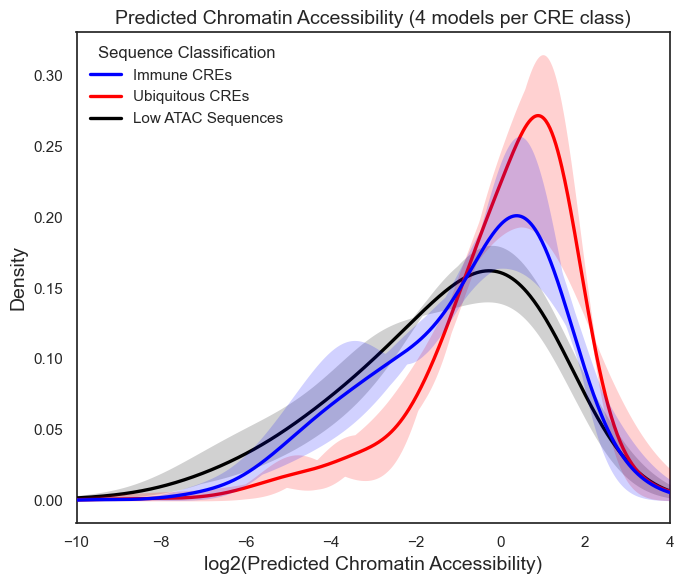

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

columns_to_combine = [
'Mouse_Cortex_AgeB-model', 'Mouse_Cortex_AgeC-model',
       'Mouse_Striatum_AgeB', 'Mouse_Striatum_AgeC'
]

# 三类数据表：df_other / df_immune / df_ubiquitous
GROUPS = {
    "Immune CREs": df_immune,
    "Ubiquitous CREs": df_ubiquitous,
    "Low ATAC Sequences": df_other,
}

# 用你源代码的颜色（更“纯”）
COLORS = {
    "Immune CREs": "blue",
    "Ubiquitous CREs": "red",
    "Low ATAC Sequences": "black",
}

def safe_log2(arr, eps=1e-8):
    arr = np.asarray(arr, dtype=float)
    arr = np.clip(arr, eps, None)
    out = np.log2(arr)
    return out[np.isfinite(out)]

def kde_on_grid(x, grid, bw_adjust=1.0):
    x = np.asarray(x, dtype=float)
    if x.size < 5:
        return None
    kde = gaussian_kde(x, bw_method=lambda k: k.scotts_factor() * bw_adjust)
    return kde(grid)

# --- plot settings ---
x_min, x_max = -10, 4
grid = np.linspace(x_min, x_max, 600)
ci_lo, ci_hi = 2.5, 97.5   # 95% band
bw_adjust = 1.0

show_thin_model_lines = False  # 只想要 band+mean 就 False
thin_alpha = 0.10              # 如果 show_thin_model_lines=True, 这个控制8条线淡不淡
band_alpha = 0.18

plt.figure(figsize=(7, 6))

# 控制叠放层级：immune 最上
Z = {"Immune CREs": 30, "Ubiquitous CREs": 20, "Low ATAC Sequences": 10}

for group_name, dfg in GROUPS.items():
    densities = []

    for col in columns_to_combine:
        vals = safe_log2(dfg[col].to_numpy())
        dens = kde_on_grid(vals, grid, bw_adjust=bw_adjust)
        if dens is None:
            continue
        densities.append(dens)

        if show_thin_model_lines:
            plt.plot(
                grid, dens,
                color=COLORS[group_name],
                alpha=thin_alpha,
                linewidth=1.0,
                zorder=Z[group_name] - 2
            )

    densities = np.vstack(densities)

    mean_d = densities.mean(axis=0)
    lo = np.percentile(densities, ci_lo, axis=0)
    hi = np.percentile(densities, ci_hi, axis=0)

    # 先画 interval（更底层）
    plt.fill_between(
        grid, lo, hi,
        color=COLORS[group_name],
        alpha=band_alpha,
        linewidth=0,
        zorder=Z[group_name] - 1
    )

    # 再画 mean（确保在 band 上面）
    plt.plot(
        grid, mean_d,
        color=COLORS[group_name],
        linewidth=2.4,
        zorder=Z[group_name],
        label=group_name
    )

plt.xlabel("log2(Predicted Chromatin Accessibility)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.title("Predicted Chromatin Accessibility (4 models per CRE class)", fontsize=14)
plt.xlim(x_min, x_max)
# plt.ylim(0, 0.45)
plt.savefig(f'densityplot_enhancer_type_immune.pdf', dpi=300, bbox_inches='tight')
plt.legend(title="Sequence Classification", frameon=False)
plt.tight_layout()
plt.savefig(f'densityplot_enhancer_type_brain.pdf', dpi=300, bbox_inches='tight')
plt.show()
